# Langgraph System for Expense Tracker Application


#### Initializing the model instance

In [28]:
import os
from dotenv import load_dotenv
from langchain_openrouter import ChatOpenRouter
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

google_api = os.getenv("GEMINI_API_KEY")
open_router_api = os.getenv("OPENROUTER_API")
tavily_api = os.getenv("TAVILY_API_KEY")

llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature = 0
)

llm3 = ChatGoogleGenerativeAI(
    model = "models/gemini-3-flash-preview",
    temperature = 0
)

llm2 = ChatOpenRouter(
    model = "meta-llama/llama-3.2-3b-instruct:free",
    temperature = 0,
    api_key = open_router_api
)

#### Defining the Graph State

In [51]:
from typing import List, Optional, Dict, Any
from pydantic import BaseModel, Field

# This is our shared state across all nodes
class GraphState(BaseModel):
    # --- Input Data (Mandatory at start) ---
    image_path: str
    # Note: We use Dict[str, Any] for better compatibility with JSON-like metadata
    trip_metadata: Dict[str, Any] = Field(default_factory=lambda: {
        "trip_currencies": ["USD", "INR"],
        "locations": ["Mumbai", "New York"],
        "window": ["2026-03-20", "2026-03-25"],
        "budget_limit": "500 USD",
        "description": "Business trip for tech conference"
    })
    
    # --- Extraction Results (Optional at start) ---
    is_readable: bool = True
    is_receipt: bool = True
    merchant_name: Optional[str] = None
    merchant_location: Optional[str] = None
    receipt_date: Optional[str] = Field(default=None, description="Date of the receipt in YYYY-MM-DD format")
    receipt_time: Optional[str] = None
    receipt_tax_id: Optional[str] = Field(default=None, description="VAT ID, GST ID, etc.")
    receipt_amount: float = 0.0
    currency: str = "USD"
    items_list: List[str] = Field(default_factory=list)
    extracted_description: Optional[str] = Field(default=None, description="Short description of image")
    
    # --- Authenticity and Results ---
    is_authentic: bool = False
    auth_violations: List[str] = Field(default_factory = list)

    # --- Policy Node Results ---
    is_relevant: bool = False
    is_policy_violating: bool = False
    policy_violations: List[str] = Field(default_factory=list)
    policy_pages: List[int] = Field(default_factory=list)
    
    # --- Final Decision ---
    decision: str = "" # approved, disapproved, flagged
    justification: List[str] = Field(default_factory=list)

#### Creating the Graph Dummy

In [15]:
# Defining all the routing functions

def extraction_decision(state: GraphState):
    if state.is_readable and state.is_receipt:
        return "authenticity"
    return "decision"

def authenticity_decision(state: GraphState):
    """
    This is the routing function to determine if we go from authenticity node to policy node or to decision node
    """
    if state.is_authentic:
        return "policy"
    return "decision"

##### Extraction Node

In [4]:
import base64
import mimetypes # Built-in python lib to detect file type
from langchain.messages import HumanMessage


class RecieptExtraction(BaseModel):
    """Structured data extracted from a business travel receipt."""
    
    is_readable: bool = Field(description="Whether the image is a clear, readable receipt.")
    is_receipt: bool = Field(description="Whether the uploaded image is actually a receipt and not a random photo.")
    merchant_name: Optional[str] = Field(description="The name of the vendor or store.")
    merchant_location: Optional[str] = Field(description="The city or address of the merchant.")
    receipt_date: Optional[str] = Field(description="The date on the receipt in YYYY-MM-DD format.")
    receipt_amount: float = Field(default=0.0, description="The total amount shown on the receipt.")
    receipt_tax_id: Optional[str] = Field(description="This can be a VAT ID, GST ID, or any other tax identification number.")
    currency: str = Field(default="USD", description="The currency code (e.g., USD, EUR, INR).")
    items_list: list[str] = Field(default_factory=list, description="A list of items purchased (e.g., ['Coffee', 'Sandwich']).")
    extracted_description: str = Field(description="A short description of the extracted image in 2-3 sentences")


def extraction_node(state: GraphState):
    print("--- NODE: Extraction (Vision) ---")
    structured_llm = llm.with_structured_output(RecieptExtraction)

    image_path = state.image_path
    
    # 1. Detect MIME type dynamically (jpeg, png, etc.)
    mime_type, _ = mimetypes.guess_type(image_path)
    if not mime_type:
        mime_type = "image/jpeg" # Fallback

    # 2. Turn the image into base64
    with open(image_path, "rb") as image_file:
        base64_image = base64.b64encode(image_file.read()).decode("utf-8")
    
    # 3. Create the Message
    # PRO-TIP: Be explicit about the JSON format in the prompt
    prompt = "Analyze this image. First, determine if it is a readable receipt. If so, extract the details."

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:{mime_type};base64,{base64_image}" 
                }
            }
        ]
    )

    # 4. Call the structured LLM
    try:
        response = structured_llm.invoke([message])
        
        print(f"\t> Success: {response.is_readable} | Merchant: {response.merchant_name}")

        return {
            "is_readable": response.is_readable, # This triggers your routing logic
            "is_receipt": response.is_receipt,
            "merchant_name": response.merchant_name or "Unknown",
            "merchant_location": response.merchant_location or "Unknown",
            "receipt_date": response.receipt_date,
            "receipt_amount": float(response.receipt_amount or 0.0),
            "receipt_tax_id": response.receipt_tax_id or None,
            "currency": response.currency or "Cannot Understand",
            "items_list": response.items_list,
            "extracted_description": response.extracted_description
        }
    except Exception as e:
        print(f"   > ERROR in Extraction: {e}")
        return {"is_readable": False, "violations": [f"Extraction Error: {str(e)}"]}

#### Creating the Authenticity Node

This node will check the following

* Checks if the Date is in the correct window
* Checks if the currency is matching in the trip_currency list
* Checks if the Merchant is located in trip_location
* Returns is_authentic 

In [65]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(max_results = 5)

class AuthenticityResult(BaseModel):
    location_match: bool = Field(description="Returns true if the merchant actually exists in any of the trip locations")
    explanation: Optional[str] = Field(description="Explain the decision of location_match")

def authenticity_node(state: GraphState): # Fixed: added 'state' parameter
    print("--- NODE: Authenticity ---")
    is_authentic = True
    viol = []
    
    # 1. Date Window Check
    start_date, end_date = state.trip_metadata["window"]
    if not (start_date <= state.receipt_date <= end_date):
        is_authentic = False
        viol.append(f"Receipt date {state.receipt_date} is outside trip window ({start_date} to {end_date})")
    print("\t>Dates OK\n")

    # 2. Currency Check
    # Assuming 'trip_currency' is a list like ['USD', 'EUR']
    if state.currency not in state.trip_metadata.get("trip_currency", ["INR"]):
        is_authentic = False
        viol.append(f"Currency {state.currency} is not valid for this trip (Expected: {state.trip_metadata.get('trip_currency')})")
    
    print("\t>Currency OK\n")

    # 3. Location Verification (Tavily + LLM)
    search_query = f"{state.merchant_name} address {state.merchant_location}"
    print(f"   > Searching: {search_query}")
    search_results = tavily_search_tool.invoke(search_query)

    prompt = f"""
    Verify if the merchant '{state.merchant_name}' located at '{state.merchant_location}' 
    actually exists in any of these trip locations: {state.trip_metadata.get('locations')}.
    
    Search Results: {search_results}
    """

    try:
        verify_llm = llm.with_structured_output(AuthenticityResult)
        response = verify_llm.invoke([HumanMessage(content=prompt)])
        
        if not response.location_match:
            is_authentic = False
            viol.append(f"Merchant '{state.merchant_name}' not verified in trip locations.")
            
    except Exception as e:
        print(f"   > Error in verification: {e}")
        viol.append("Technical error during location verification.")
    
    print("\t>Location OK\n" if response.location_match else "\t>Location NOT OK")
    print(response.explanation)

    return {
        "is_authentic": is_authentic,
        "auth_violations": state.auth_violations + viol
    }

#### Decision Node
The decision will be taken on the following matters (approve/disapprove)
* If image is readable
* If it is not a receipt
* It violates authenticity
* It violates any company policy

In [10]:
class DecisionNodeResult(BaseModel):
    is_approved: bool = Field(description = "True if the receipt is approved")
    justification: List[str] = Field(default_factory=list)

def decision_node(state: GraphState):
    print("--- NODE: Decision ---")
    
    # 1. Convert Pydantic state to a dict to filter it safely
    exclude_keys = {"is_authentic", "is_relevant", "is_policy_violating", "decision"}
    data_for_llm = {k: v for k, v in state.model_dump().items() if k not in exclude_keys}
    
    prompt = f"""
    You are an expert corporate auditor. Based on the following receipt data and travel metadata, 
    decide if this expense should be Approved or Disapproved.
    
    AUDIT DATA:
    {data_for_llm}

    GUIDELINES:
    - If there are any 'auth_violations' or 'policy_violations', you MUST Disapprove.
    - Provide exactly 1-3 bullet points of justification only if you disapproved.
    - Be professional and concise.
    """

    try:
        # Using your fallback-enabled LLM is best here
        primary_judge = llm.with_structured_output(DecisionNodeResult)
        response = primary_judge.invoke([HumanMessage(content=prompt)])
        
        # Determine status string
        status = "approved" if response.is_approved else "disapproved"
        
        # Combine existing justifications with the new LLM verdict
        return {
            "decision": status,
            "justification": state.justification + response.justification
        }

    except Exception as e:
        print(f"   > Error in Decision node: {e}")
        return {
            "decision": "flagged", 
            "justification": state.justification + ["System error during final audit. Manual review required."]
        }

### Creating Policy Node

In [22]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

file = "policy.pdf"
loader = PyPDFLoader(file)

docs = loader.load()

# splitting the documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 256,
    chunk_overlap = 50,
    add_start_index = True
)

all_splits = text_splitter.split_documents(docs)
print(f"Split policy into {len(all_splits)} sub-documents.")

Split policy into 55 sub-documents.


In [29]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

# creating the model and embeddings
model = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    api_key = google_api
    )
embeddings = GoogleGenerativeAIEmbeddings(
    model = "models/gemini-embedding-001",
    api_key = google_api
    )

#creating the vector storee
vector_store = Chroma(
    collection_name = "policy_collection",
    embedding_function = embeddings,
    persist_directory = "./policy_db"
)

# Storing documents
document_ids = vector_store.add_documents(documents = all_splits)



In [30]:
from langchain.tools import tool

@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve information to help answer a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

In [56]:
from langchain.agents import create_agent

class PolicyNodeResult(BaseModel):
    is_relevant: bool = False
    is_policy_violating: bool = False
    policy_violations: List[str] = Field(default_factory=list, description="Contains all policy violations")
    policy_pages: List[int] = Field(default_factory=list, description="contains pages of rules violated by receipt")



tools = [retrieve_context]
# If desired, specify custom instructions
system_prompt = (
    "You are a strict Corporate Compliance Agent. "
    "Use the retrieve_context tool to search the company policy for every item listed in the receipt. "
    "If an item (like alcohol) is forbidden or a category (like meals) has a price limit, "
    "If it is violating any policy, is_policy_violating = True and give detailed description of each violation"
    "You also need to check if the given items are relevant to the trip.(eg. things like going to disney park etc)"
    "explicitly state the violation. If you are unsure or the context is missing, flag it for review."
)
agent = create_agent(
    model,
    tools, 
    system_prompt=system_prompt, 
    response_format=PolicyNodeResult)

In [53]:
from langchain.messages import HumanMessage



ques = "Can an employee claim reimbursement for a movie ticket during a business trip?"
query = HumanMessage(content = ques)

response = agent.invoke({
    "messages":[query]
})

In [58]:
print(response["structured_response"].policy_violations)

['Entertainment (Cinema, Sports tickets) unless part of a client event.']


In [62]:
class PolicyNodeResult(BaseModel):
    is_relevant: bool = False
    is_policy_violating: bool = False
    policy_violations: List[str] = Field(default_factory=list, description="Contains all policy violations")
    policy_pages: List[int] = Field(default_factory=list, description="contains pages of rules violated by receipt")

system_prompt = (
    "You are a strict Corporate Compliance Agent. "
    "Use the retrieve_context tool to search the company policy for every item listed in the receipt. "
    "If an item (like alcohol) is forbidden or a category (like meals) has a price limit, "
    "You also need to check if the given items are relevant to the trip.(eg. things like going to disney park etc)"
    "explicitly state the violation. If you are unsure or the context is missing, flag it for review."
)
agent = create_agent(
    model,
    tools, 
    system_prompt=system_prompt,
    response_format = PolicyNodeResult)

def policy_check_node(state: GraphState):
    print("--- NODE: Policy Check ---")
    
    exclude_keys = {"is_authentic", "auth_violations","is_readable", "is_receipt","is_relevant", "is_policy_violating", "decision", "justification"}
    data_for_llm = {k: v for k, v in state.model_dump().items() if k not in exclude_keys}

    prompt = f"""
    Data extracted from the image.\n\n{data_for_llm}\n\n
    Trip Metadata is the information about the trip extracted from the Database
    Use these to check for any policy violations and relevancy of the receipt.
    """
    query = HumanMessage(content = prompt)

    try:
        response = agent.invoke({
            "messages": [query]
        })
        print(f"\t>Policy Node: {response["structured_response"]}")

        return {
            "is_relevant":response["structured_response"].is_relevant,
            "is_policy_violating":response["structured_response"].is_policy_violating,
            "policy_violations": state.policy_violations + response["structured_response"].policy_violations,
            "policy_pages": state.policy_pages + response["structured_response"].policy_pages
        }
    except Exception as e:
        print(f"\t> Error in Policy node: {str(e)}") # Fixed exception printing
        return {
            "is_policy_violating": False,
            "policy_violations": ["Technical error during policy audit."]
        }
    

Graph Skeleton Compiled!


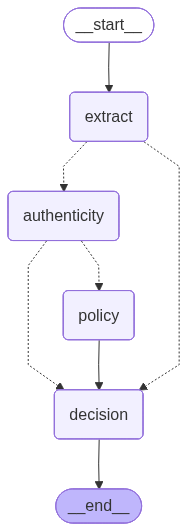

In [66]:
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# --- Build the Graph ---

graph = StateGraph(GraphState)

# 1. Add Nodes
graph.add_node("extract", extraction_node)
graph.add_node("authenticity", authenticity_node)
graph.add_node("policy", policy_check_node)
graph.add_node("decision", decision_node)

# 2. Define Edges (The Flow)
graph.set_entry_point("extract")
graph.add_conditional_edges(
    "extract", 
    extraction_decision,
    {
        "authenticity": "authenticity",
        "decision": "decision"
    })
graph.add_conditional_edges(
    "authenticity", 
    authenticity_decision,
    {
        "policy": "policy",
        "decision": "decision"
    })

graph.add_edge("policy", "decision")
graph.add_edge("decision", END)

# 3. Compile
app = graph.compile()
print("Graph Skeleton Compiled!")

display(Image(app.get_graph().draw_mermaid_png()))

#### Lets make a dummy run on the graph

In [ ]:
initial_input = {
    "image_path": "bar.jpg",
    "trip_metadata": {
        "locations": ["New York", "Faridabad", "London"],
        "window": ["2016-07-20", "2016-07-30"],
        "budget_limit": "500 USD",
        "description": "Business trip for tech conference",
        "trip_currencies": ["USD", "INR"]
    }
}

print("--- STARTING HAPPY PATH RUN ---")
final_state = app.invoke(initial_input)

print("\n--- FINAL RESULTS ---")
print(f"Decision: {final_state['decision']}")
print(f"Merchant: {final_state.get('merchant_name')}")
print(f"Justification: {final_state['justification']}")

--- STARTING HAPPY PATH RUN ---
--- NODE: Extraction (Vision) ---
	> Success: True | Merchant: THE DANCING BEARS
--- NODE: Authenticity ---
	>Dates OK

	>Currency OK

   > Searching: THE DANCING BEARS address 2384 Saranac Ave Lake Placid, NY
	>Location OK

The merchant 'THE DANCING BEARS' is located at '2384 Saranac Ave Lake Placid, NY'. Lake Placid is a village in New York State, which is one of the specified trip locations.
--- NODE: Decision ---
   > Error in Decision node: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 35.

In [72]:
for item in final_state:
    print(f"{item}:{final_state[item]}")

image_path:bar.jpg
trip_metadata:{'locations': ['New York', 'Faridabad', 'London'], 'window': ['2016-07-20', '2016-07-30'], 'budget_limit': '500 USD', 'description': 'Business trip for tech conference'}
is_readable:True
is_receipt:True
merchant_name:THE DANCING BEARS
merchant_location:2384 Saranac Ave Lake Placid, NY
receipt_date:2016-07-28
receipt_tax_id:None
receipt_amount:15.98
currency:USD
items_list:['8 D/Yuengling', 'Beer']
extracted_description:This image is a clear and readable receipt from The Dancing Bears located in Lake Placid, NY. It details a purchase made on July 28, 2016, totaling $15.98, primarily for beer. The receipt explicitly states that it is not a final receipt.
is_authentic:False
auth_violations:['Currency USD is not valid for this trip (Expected: None)']
decision:flagged
justification:['System error during final audit. Manual review required.']
